In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:

df = pd.read_csv('dataset/gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,emaar mgf the palm drive,sector 66,3.98,18091.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,2200.0,NaN,NaN,0,1,0,0,0,1,123,733.333333
1,flat,emaar digihomes,sector 62,2.15,14257.0,1508.0,Carpet area: 1508 (140.1 sq.m.),2,2,3,31.0,NaN,Under Construction,NaN,NaN,1508.0,0,0,0,0,0,0,101,754.000000
2,flat,m3m heights,sector 65,2.44,13297.0,1835.0,Super Built up area 1828(169.83 sq.m.),3,3,2,7.0,NaN,Under Construction,1828.0,NaN,NaN,0,0,0,0,0,0,31,611.666667
3,flat,the close south,sector 50,3.10,12445.0,2491.0,Super Built up area 2491(231.42 sq.m.)Built Up...,3,4,3+,4.0,North-East,Moderately Old,2491.0,2450.0,2250.0,0,1,0,0,0,1,165,830.333333
4,flat,unitech the residences,sector 33,1.55,9873.0,1570.0,Super Built up area 1570(145.86 sq.m.),3,4,1,1.0,South,Relatively New,1570.0,NaN,NaN,0,1,0,0,0,0,37,523.333333


In [5]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1968
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

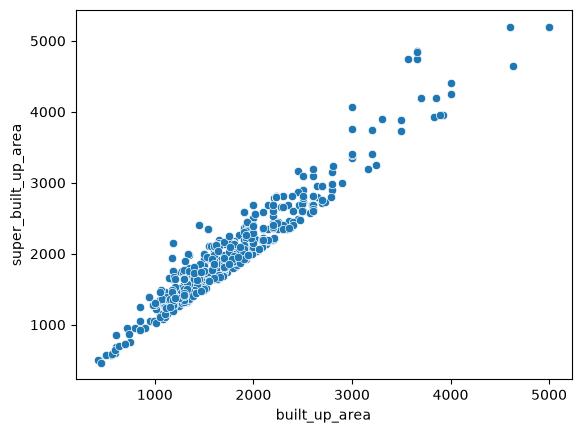

In [7]:
sns.scatterplot(data=df,x='built_up_area',y='super_built_up_area')

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

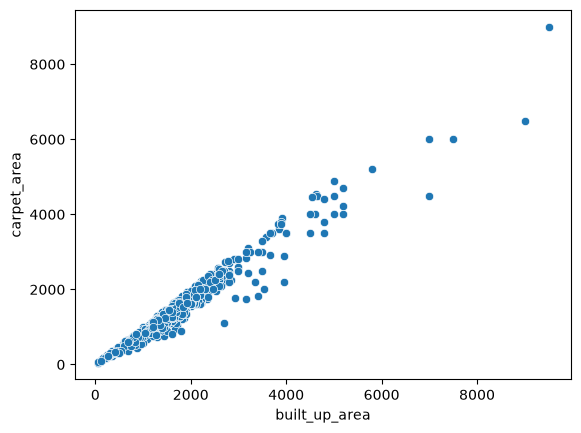

In [9]:
sns.scatterplot(data=df,x='built_up_area',y='carpet_area')

In [10]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3550    False
3551    False
3552    False
3553    False
3554    False
Length: 3555, dtype: bool

In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
all_present_df.shape

(531, 24)

In [13]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [14]:
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [15]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
12,flat,shree vardhman flora,sector 90,0.92,4907.0,1875.0,Super Built up area 1875(174.19 sq.m.)Carpet a...,3,4,3,4.0,North-East,Relatively New,1875.0,NaN,1161.0,0,1,0,0,0,0,116,625.0
19,flat,signature global city 92,sector 92,0.78,11143.0,700.0,Super Built up area 1010(93.83 sq.m.)Carpet ar...,2,2,3,2.0,NaN,Under Construction,1010.0,NaN,700.0,0,0,0,0,1,0,24,350.0
22,flat,rof ananda,sector 95,0.55,8527.0,645.0,Super Built up area 1000(92.9 sq.m.)Carpet are...,3,2,2,14.0,East,New Property,1000.0,NaN,645.0,1,0,0,0,0,1,81,215.0
23,flat,alpha corp gurgaonone,sector 84,1.15,7497.0,1534.0,Super Built up area 1534(142.51 sq.m.)Carpet a...,2,2,3,14.0,South-East,Relatively New,1534.0,NaN,1260.0,1,0,0,0,0,0,28,767.0
44,flat,green court,sector 90,0.50,8333.0,600.0,Super Built up area 700(65.03 sq.m.)Carpet are...,2,2,1,8.0,NaN,New Property,700.0,NaN,600.0,0,0,0,0,0,0,42,300.0


In [17]:
sbc_df=sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2))

In [18]:
df.update(sbc_df)

In [19]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1547
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [20]:
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [21]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,emaar mgf the palm drive,sector 66,3.98,18091.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,2200.0,NaN,NaN,0,1,0,0,0,1,123,733.333333
2,flat,m3m heights,sector 65,2.44,13297.0,1835.0,Super Built up area 1828(169.83 sq.m.),3,3,2,7.0,NaN,Under Construction,1828.0,NaN,NaN,0,0,0,0,0,0,31,611.666667
4,flat,unitech the residences,sector 33,1.55,9873.0,1570.0,Super Built up area 1570(145.86 sq.m.),3,4,1,1.0,South,Relatively New,1570.0,NaN,NaN,0,1,0,0,0,0,37,523.333333
8,flat,chd avenue,sector 71,1.10,6104.0,1802.0,Super Built up area 1802(167.41 sq.m.),3,4,3,3.0,South,Moderately Old,1802.0,NaN,NaN,0,1,0,0,0,0,26,600.666667
10,flat,sare crescent parc royal greens phase 1,sector 92,0.79,6086.0,1298.0,Super Built up area 1298(120.59 sq.m.),3,2,2,15.0,NaN,New Property,1298.0,NaN,NaN,0,0,0,0,0,0,25,432.666667


In [22]:
sb_df=sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105))

In [23]:
df.update(sb_df)

In [24]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area           672
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [25]:
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [26]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,emaar digihomes,sector 62,2.15,14257.0,1508.0,Carpet area: 1508 (140.1 sq.m.),2,2,3,31.0,NaN,Under Construction,NaN,NaN,1508.0,0,0,0,0,0,0,101,754.000000
5,flat,smart world orchard,sector 61,2.54,15497.0,1639.0,Carpet area: 1640 (152.36 sq.m.),3,3,3,2.0,NaN,Under Construction,NaN,NaN,1640.0,0,0,1,0,0,0,16,546.333333
7,flat,signature global the millennia 3,sector 37d,0.45,7627.0,590.0,Carpet area: 590 (54.81 sq.m.),2,3,2,8.0,NaN,Under Construction,NaN,NaN,590.0,0,0,0,0,0,0,8,295.000000
9,flat,vatika gurgaon,sector 83,1.19,7438.0,1600.0,Carpet area: 1600 (148.64 sq.m.),3,3,2,10.0,South,Relatively New,NaN,NaN,1600.0,0,1,0,0,0,1,35,533.333333
13,flat,palam vihar society,sector 2,3.35,7444.0,4500.0,Carpet area: 4500 (418.06 sq.m.),4,4,3+,2.0,NaN,New Property,NaN,NaN,4500.0,1,0,0,0,0,0,66,1125.000000


In [27]:
c_df=c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9))

In [28]:
df.update(c_df)